# 04 — Baseline + MLP

Pierwsze modele prognostyczne: prosty baseline (persistence + linear regression) jako punkt odniesienia, oraz pierwsza sieć neuronowa (MLP).

Wejście: okno 48h pogody i generacji + cechy czasowe.  
Wyjście: 24h prognozy `wi` i `pv`.

Pełny opis projektu w README.

## 4.1 Konfiguracja i wczytanie danych

In [ ]:
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, callbacks, Model

DATA_DIR = Path("data/processed")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

LOOKBACK = 48
HORIZON = 24
print(f"TensorFlow {tf.__version__}")

I0000 00:00:1777753468.114898 3030948 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0


Importy + konfiguracja podstawowych parametrów (lookback 48h, horizon 24h).

In [3]:
df = pd.read_csv(DATA_DIR / "dataset_full.csv", sep=";", decimal=",", parse_dates=["timestamp"]).set_index("timestamp")
print(f"zbiór: {df.shape}")
print(f"zakres: {df.index.min()} -> {df.index.max()}")
df.head()

zbiór: (26304, 47)
zakres: 2023-01-01 00:00:00 -> 2025-12-31 23:00:00


,wind100_szczecin,wind10_szczecin,rad_szczecin,rad_dir_szczecin,cloud_szczecin,temp_szczecin,wind100_slupsk,wind10_slupsk,rad_slupsk,rad_dir_slupsk,...,wdir100_cos_warszawa,wdir100_sin_krakow,wdir100_cos_krakow,is_test,wi,pv,hour_sin,hour_cos,doy_sin,doy_cos
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,13.23,8.13,0.0,0.0,100,14.9,12.66,7.56,0.0,0.0,...,-0.587785,-0.891007,-0.453990,0,5529.188,0.0,0.000000,1.000000,0.017202,0.999852
2023-01-01 01:00:00,13.09,7.92,0.0,0.0,100,14.3,13.82,8.51,0.0,0.0,...,-0.587785,-0.809017,-0.587785,0,4250.700,0.0,0.258819,0.965926,0.017202,0.999852
2023-01-01 02:00:00,12.63,7.43,0.0,0.0,100,13.9,10.98,6.31,0.0,0.0,...,-0.469472,-0.707107,-0.707107,0,3124.613,0.0,0.500000,0.866025,0.017202,0.999852
2023-01-01 03:00:00,13.27,7.99,0.0,0.0,100,14.6,14.53,8.94,0.0,0.0,...,-0.544639,-0.707107,-0.707107,0,3486.663,0.0,0.707107,0.707107,0.017202,0.999852
2023-01-01 04:00:00,13.67,8.44,0.0,0.0,100,15.3,14.40,8.88,0.0,0.0,...,-0.587785,-0.743145,-0.669131,0,4257.800,0.0,0.866025,0.500000,0.017202,0.999852


Wczytany zbiór z notebooka 03 — 26 304 wiersze, 47 kolumn.

## 4.2 Podział train / val / test

Walidacja **sezonowo zbalansowana** — 4 wycinki po 2 tygodnie z 2024 (zima, wiosna, lato, jesień). To pozwala monitorować wydajność modelu w różnych warunkach pogodowych podczas strojenia. Test = cały 2025 z prognozami pogodowymi (już oznaczone w `is_test`).

In [4]:
val_periods = [
    ("zima",   "2024-02-12", "2024-02-25"),
    ("wiosna", "2024-05-13", "2024-05-26"),
    ("lato",   "2024-08-12", "2024-08-25"),
    ("jesien", "2024-11-11", "2024-11-24"),
]

is_val = pd.Series(False, index=df.index)
for name, start, end in val_periods:
    is_val.loc[start:end] = True

is_test = df["is_test"].astype(bool)
is_train = ~is_val & ~is_test

df_train = df[is_train]
df_val = df[is_val]
df_test = df[is_test]

print(f"train: {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"val:   {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")
print(f"test:  {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")

train: 16200 (61.6%)
val:   1344 (5.1%)
test:  8760 (33.3%)


~62% train, 5% val, 33% test. Test jest duży bo to cały 2025, val celowo mała ale sezonowo zbalansowana.

## 4.3 Generowanie okien

Każda próbka treningowa odpowiada **jednej prognozie**: o godzinie `t` chcemy przewidzieć generację dla `[t, t+24h]`. Sieć dostaje na wejście dwie rzeczy:

In [6]:
TARGETS = ["wi", "pv"]
EXCLUDE = ["is_test"]
WEATHER_COLS = [c for c in df.columns if c not in TARGETS + EXCLUDE]
HIST_COLS = [c for c in df.columns if c not in EXCLUDE]


def make_windows(data: pd.DataFrame, lookback: int = LOOKBACK, horizon: int = HORIZON):
    """
    Generuje okna przesuwane co 1h.
    X: dla każdego punktu t: [lookback historii (pogoda+target+cechy czasowe)] + [horizon przyszłej pogody]
    y: [horizon kolejnych godzin wi i pv]
    Zwraca też timestamps - moment startu prognozy.
    """
    X_list, y_list, ts_list = [], [], []
    n = len(data)

    for t in range(lookback, n - horizon):
        hist = data[HIST_COLS].iloc[t - lookback:t]
        future = data[WEATHER_COLS].iloc[t:t + horizon]
        target = data[TARGETS].iloc[t:t + horizon]

        x_flat = np.concatenate([hist.values.flatten(), future.values.flatten()])
        X_list.append(x_flat)
        y_list.append(target.values.flatten())
        ts_list.append(data.index[t])

    return np.array(X_list), np.array(y_list), pd.DatetimeIndex(ts_list)


X_train, y_train, ts_train = make_windows(df_train)
print(f"train okna: X={X_train.shape}, y={y_train.shape}")

train okna: X=(16128, 3264), y=(16128, 48)


**W historii** są wszystkie kolumny (pogoda + targety wi/pv + cechy czasowe), bo sieć widzi "co się działo do tej pory".

**W przyszłej pogodzie** są tylko featury pogodowe — bo w realnej produkcji tego nie znamy ("ile będzie wygenerowane jutro"). To właśnie przewidujemy.

**Cechy czasowe** (sin/cos godziny i dnia roku) niosą informację gdzie jesteśmy w cyklu dobowym i rocznym — to kluczowe dla PV (cykl słońca) i częściowo dla wiatru (sezonowość).

Wyjście to spłaszczona macierz 24h × 2 targety = 48 wartości w kolejności `[wi_t, pv_t, wi_t+1, pv_t+1, ..., wi_t+23, pv_t+23]`.

Liczba okien w trainie: `16 200 - 48 - 24 = 16 128` (pierwsze 48h "zjada" lookback, ostatnie 24h "zjada" horizon).

In [7]:
X_val, y_val, ts_val = make_windows(df_val)
print(f"val okna: X={X_val.shape}, y={y_val.shape}")

val okna: X=(1272, 3264), y=(1272, 48)


Val ma znacznie mniej okien bo pochodzi z 4 niespójnych wycinków.

## 4.4 Skalowanie

`StandardScaler` fitujemy **tylko na trainie**, transformujemy na val i test. Skalujemy osobno X (featury pogodowe + targety w historii) i y (targety w outpucie) — żeby móc odwrócić predykcje z powrotem do MW.

In [8]:
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
y_train_s = scaler_y.transform(y_train)
y_val_s   = scaler_y.transform(y_val)

print(f"X_train_s: mean={X_train_s.mean():.3f}, std={X_train_s.std():.3f}")
print(f"y_train_s: mean={y_train_s.mean():.3f}, std={y_train_s.std():.3f}")

X_train_s: mean=-0.000, std=1.000
y_train_s: mean=-0.000, std=1.000


Po skalowaniu `X_train_s` ma średnią ~0 i odchylenie ~1 (z definicji StandardScaler). Val nie ma idealnie 0/1 — i to dobrze, bo skaler nie widział tych danych podczas fitu.

## 4.5 Baseline 1 — Persistence

"Generacja jutro o godz. X = generacja dziś o godz. X". Najprymitywniejszy benchmark — jeśli model nie pobije persistence, to jest zupełnie bezużyteczny.

In [9]:
def persistence_baseline(data: pd.DataFrame, ts: pd.DatetimeIndex, horizon: int = HORIZON):
    """Dla każdego t zwraca jako prognozę: dane sprzed 24h dla [t, t+24]."""
    preds = []
    for t in ts:
        prev = data.loc[t - pd.Timedelta(hours=24):t - pd.Timedelta(hours=1), TARGETS]
        preds.append(prev.values.flatten())
    return np.array(preds)


y_pred_persistence = persistence_baseline(df, ts_val)
print(f"shape: {y_pred_persistence.shape}")

shape: (1272, 48)


Dla każdej próbki walidacyjnej bierzemy jako prognozę dane sprzed 24h. Wynik ma ten sam kształt co `y_val`.

## 4.6 Baseline 2 — Linear Regression

Standardowy benchmark dla deep learning. Ten sam input co MLP (3264 cechy), tylko liniowa relacja. Pokazuje "ile można wyciągnąć z liniowej zależności" — jeśli MLP nie pobije linear regression, to nieliniowość niczego nie wnosi.

In [10]:
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train_s, y_train_s)

y_pred_lr_s = lr.predict(X_val_s)
y_pred_lr = scaler_y.inverse_transform(y_pred_lr_s)

print(f"linear regression dopasowany, parametrów: {lr.coef_.size}")

linear regression dopasowany, parametrów: 156672


~157 000 parametrów (3264 wejścia × 48 wyjść). Trenuje się parę sekund na CPU. Nie myli go skala — rozwiązuje równanie liniowe.

## 4.7 Funkcje metryk

In [11]:
def compute_metrics(y_true, y_pred, label=""):
    y_true = y_true.reshape(-1, HORIZON, 2)
    y_pred = y_pred.reshape(-1, HORIZON, 2)

    metrics = {}
    for i, name in enumerate(TARGETS):
        mae = mean_absolute_error(y_true[:, :, i].flatten(), y_pred[:, :, i].flatten())
        rmse = np.sqrt(mean_squared_error(y_true[:, :, i].flatten(), y_pred[:, :, i].flatten()))
        metrics[f"{name}_MAE"] = mae
        metrics[f"{name}_RMSE"] = rmse

    if label:
        print(f"\n{label}")
        for k, v in metrics.items():
            print(f"  {k}: {v:.1f} MW")
    return metrics


m_persistence = compute_metrics(y_val, y_pred_persistence, "Persistence")
m_lr          = compute_metrics(y_val, y_pred_lr, "Linear Regression")


Persistence
  wi_MAE: 1498.5 MW
  wi_RMSE: 1963.5 MW
  pv_MAE: 514.0 MW
  pv_RMSE: 1107.9 MW

Linear Regression
  wi_MAE: 832.8 MW
  wi_RMSE: 1485.7 MW
  pv_MAE: 603.0 MW
  pv_RMSE: 1222.8 MW


MAE i RMSE w MW dla `wi` i `pv` osobno. Te liczby są naszym **punktem odniesienia** — MLP musi je pobić.

**Obserwacja:** Persistence pobija Linear Regression dla `pv` (514 vs 603 MW MAE), ale przegrywa dla `wi` (1498 vs 833 MW). Wynika to z natury obu zjawisk:

- **PV ma silny cykl dobowy** (zera w nocy, charakterystyczny łuk w dzień). Persistence świetnie go chwyta — sąsiednie dni są często podobne. Linear regression próbuje liniowo uogólnić nieliniową zależność `pogoda → PV` (saturacja, próg radiacji) i robi większe błędy.
- **Wiatr nie ma cyklu dobowego**, ale silnie zależy od pogody synoptycznej (prędkość wiatru → generacja). Linear regression dobrze chwyta tę zależność, persistence radzi sobie słabo bo wiatr potrafi się zmienić z godziny na godzinę.

To pokazuje że nasza sieć MLP musi nauczyć się **obu** rzeczy: nieliniowej zależności od pogody (lepszej niż linear) i wzorców czasowych (lepszych niż persistence). Jeśli pobije oba baseliny we wszystkich metrykach, mamy potwierdzenie że deep learning faktycznie wnosi wartość.

### Diagnostyka — czemu Linear Regression jest gorszy od persistence dla PV?

In [12]:
print(f"min y_pred_lr: {y_pred_lr.min():.1f}")
print(f"% predykcji ujemnych: {(y_pred_lr < 0).mean()*100:.1f}%")

min y_pred_lr: -8836.9
% predykcji ujemnych: 18.9%


Hipoteza potwierdzona: ~19% predykcji Linear Regression jest ujemnych, z minimum -8836 MW. To fizycznie niemożliwe — generacja `wi` i `pv` zawsze ≥ 0. Linear regression nie ma jak wiedzieć o tym ograniczeniu, więc ekstrapoluje liniowo nawet poza realny zakres. Persistence tego problemu nie ma (kopiuje historyczne nieujemne wartości), MLP też nie powinien (nauczy się rozkładu na trainie). To dodatkowy powód dlaczego linear regression jest słaby dla `pv` — duże ujemne predykcje w nocy podbijają MAE.

## 4.8 MLP — architektura

Sieć MLP z trzema warstwami ukrytymi: 256 → 128 → 48 (output). Łącznie ~620 000 parametrów. Dropout 0.2 i BatchNormalization jako regularyzacja.

**Wejście:** 3264 (spłaszczone okno 48h historii + 24h przyszłej pogody)  
**Wyjście:** 48 (24h × 2 targety)

In [13]:
def build_mlp(input_dim: int, output_dim: int = HORIZON * len(TARGETS)) -> Model:
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(output_dim, activation="linear")(x)
    model = Model(inp, out, name="mlp")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


tf.keras.utils.set_random_seed(42)
mlp = build_mlp(X_train_s.shape[1])
mlp.summary()

I0000 00:00:1777754524.046422 3030948 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 702 MB memory:  -> device: 0, name: NVIDIA TITAN RTX, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1777754524.047972 3030948 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22804 MB memory:  -> device: 1, name: NVIDIA TITAN RTX, pci bus id: 0000:21:00.0, compute capability: 7.5


Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3264)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       835,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 48)             │         6,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875,952 (3.34 MB)

 Trainable params: 875,440 (3.34 MB)

 Non-trainable params: 512 (2.00 KB)

Optimizer: Adam z learning rate 1e-3 (standardowy startowy). Loss: MSE (penalizuje duże błędy mocniej, dobre dla regresji). Dodatkowo monitorujemy MAE.

## 4.9 Trening

In [14]:
es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)

history = mlp.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=100,
    batch_size=128,
    callbacks=[es, rlr],
    verbose=2,
)

Epoch 1/100


I0000 00:00:1777754551.145021 3041036 service.cc:153] XLA service 0x76d3c0031f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777754551.145052 3041036 service.cc:161]   StreamExecutor [0]: NVIDIA TITAN RTX, Compute Capability 7.5 (Driver: 12.7.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.0)
I0000 00:00:1777754551.145060 3041036 service.cc:161]   StreamExecutor [1]: NVIDIA TITAN RTX, Compute Capability 7.5 (Driver: 12.7.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.7.0)
I0000 00:00:1777754551.188438 3041036 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777754551.334212 3041036 cuda_dnn.cc:461] Loaded cuDNN version 90700
I0000 00:00:1777754551.387730 3041036 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1785__.14
I0000 00:00:1777754553.048376 3041036 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at 

126/126 - 4s - 29ms/step - loss: 0.5076 - mae: 0.5391 - val_loss: 0.1629 - val_mae: 0.3046 - learning_rate: 0.0010
Epoch 2/100
126/126 - 0s - 3ms/step - loss: 0.2303 - mae: 0.3696 - val_loss: 0.1328 - val_mae: 0.2680 - learning_rate: 0.0010
Epoch 3/100
126/126 - 0s - 3ms/step - loss: 0.1656 - mae: 0.3107 - val_loss: 0.1159 - val_mae: 0.2467 - learning_rate: 0.0010
Epoch 4/100
126/126 - 0s - 3ms/step - loss: 0.1325 - mae: 0.2757 - val_loss: 0.1037 - val_mae: 0.2303 - learning_rate: 0.0010
Epoch 5/100
126/126 - 0s - 3ms/step - loss: 0.1125 - mae: 0.2524 - val_loss: 0.1011 - val_mae: 0.2259 - learning_rate: 0.0010
Epoch 6/100
126/126 - 0s - 3ms/step - loss: 0.1008 - mae: 0.2376 - val_loss: 0.0974 - val_mae: 0.2195 - learning_rate: 0.0010
Epoch 7/100
126/126 - 0s - 3ms/step - loss: 0.0917 - mae: 0.2253 - val_loss: 0.0870 - val_mae: 0.2092 - learning_rate: 0.0010
Epoch 8/100
126/126 - 0s - 3ms/step - loss: 0.0847 - mae: 0.2160 - val_loss: 0.0849 - val_mae: 0.2033 - learning_rate: 0.0010
Epo

EarlyStopping zatrzymuje trening gdy val_loss nie poprawia się przez 10 epok i przywraca najlepsze wagi. ReduceLROnPlateau zmniejsza learning rate gdy trening utknie.

## 4.10 Krzywe uczenia

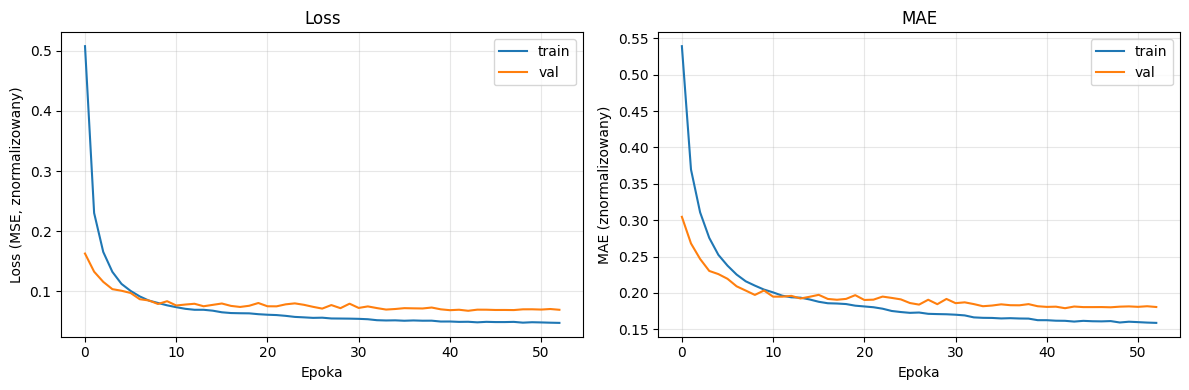

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("Loss (MSE, znormalizowany)")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="val")
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("MAE (znormalizowany)")
axes[1].set_title("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Krzywe uczenia. Train spada poniżej val (lekki overfitting), ale val też spada — model uczy się sensownie. EarlyStopping przywrócił wagi z najlepszej epoki (najniższy val_loss).

## 4.11 Ewaluacja MLP na walidacji

In [16]:
y_pred_mlp_s = mlp.predict(X_val_s, verbose=0)
y_pred_mlp = scaler_y.inverse_transform(y_pred_mlp_s)

y_pred_mlp = np.clip(y_pred_mlp, 0, None)

m_mlp = compute_metrics(y_val, y_pred_mlp, "MLP")


MLP
  wi_MAE: 437.3 MW
  wi_RMSE: 573.3 MW
  pv_MAE: 373.1 MW
  pv_RMSE: 643.2 MW


Predykcje rozskalowane do MW i zaclipowane do nieujemnych (generacja fizycznie ≥ 0). MAE i RMSE w tych samych jednostkach co baseline — można porównywać bezpośrednio.

## 4.12 Porównanie wszystkich modeli

                   wi_MAE  wi_RMSE  pv_MAE  pv_RMSE
Persistence        1498.5   1963.5   514.0   1107.9
Linear Regression   832.8   1485.7   603.0   1222.8
MLP                 437.3    573.3   373.1    643.2


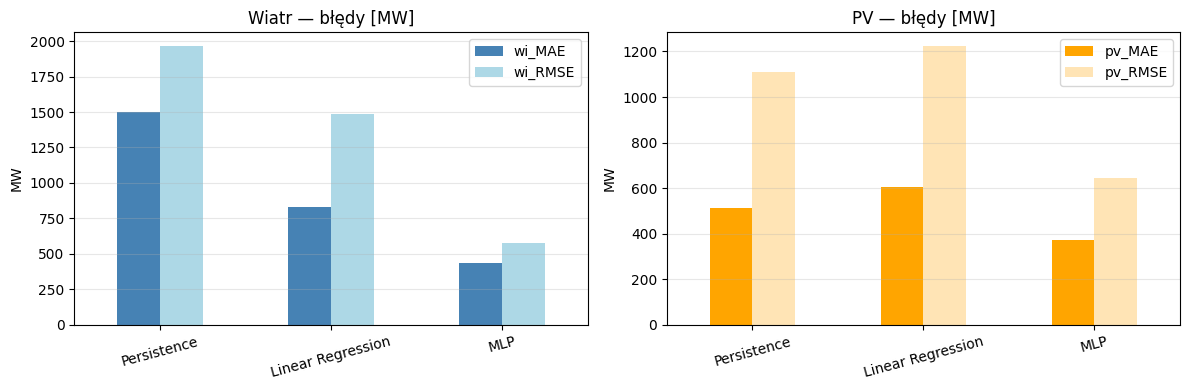

In [17]:
results = pd.DataFrame({
    "Persistence":       m_persistence,
    "Linear Regression": m_lr,
    "MLP":               m_mlp,
}).T

print(results.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results[["wi_MAE", "wi_RMSE"]].plot(kind="bar", ax=axes[0], color=["steelblue", "lightblue"])
axes[0].set_title("Wiatr — błędy [MW]")
axes[0].set_ylabel("MW")
axes[0].grid(alpha=0.3, axis="y")
axes[0].tick_params(axis="x", rotation=15)

results[["pv_MAE", "pv_RMSE"]].plot(kind="bar", ax=axes[1], color=["orange", "moccasin"])
axes[1].set_title("PV — błędy [MW]")
axes[1].set_ylabel("MW")
axes[1].grid(alpha=0.3, axis="y")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

**Wyniki:**

MLP wyraźnie pobija oba baseliny. Dla wiatru redukcja MAE z 1498 (persistence) do 437 MW — **70% poprawy**. Dla PV redukcja z 514 do 373 MW — **27% poprawy**. Względem linear regression MLP jest lepszy o 47% (`wi`) i 38% (`pv`).

Względem średniej generacji w zbiorze treningowym (~2600 MW dla `wi`, ~1740 MW dla `pv`), to przekłada się na błąd rzędu 17-21% — typowy dla prognoz day-ahead OZE w literaturze, dla pierwszego nieoptymalizowanego modelu wynik dobry.

Wniosek: nieliniowość MLP istotnie wnosi wartość, szczególnie dla wiatru gdzie zależności pogodowe są bardziej skomplikowane (krzywa mocy turbiny zachowuje się nieliniowo z $v^3$ poniżej prędkości znamionowej, a powyżej saturuje). W bloku 05 zbudujemy LSTM, który powinien dodatkowo wykorzystać sekwencyjną strukturę danych.

## 4.13 Zapis modeli i artefaktów

In [18]:
mlp.save(MODELS_DIR / "mlp.keras")
joblib.dump(scaler_X, MODELS_DIR / "scaler_X.pkl")
joblib.dump(scaler_y, MODELS_DIR / "scaler_y.pkl")
joblib.dump(lr, MODELS_DIR / "linear_regression.pkl")

predictions_val = pd.DataFrame({
    "timestamp": np.repeat(ts_val, HORIZON),
    "horizon": np.tile(np.arange(HORIZON), len(ts_val)),
    "wi_true":  y_val.reshape(-1, HORIZON, 2)[:, :, 0].flatten(),
    "pv_true":  y_val.reshape(-1, HORIZON, 2)[:, :, 1].flatten(),
    "wi_persistence": y_pred_persistence.reshape(-1, HORIZON, 2)[:, :, 0].flatten(),
    "pv_persistence": y_pred_persistence.reshape(-1, HORIZON, 2)[:, :, 1].flatten(),
    "wi_lr": y_pred_lr.reshape(-1, HORIZON, 2)[:, :, 0].flatten(),
    "pv_lr": y_pred_lr.reshape(-1, HORIZON, 2)[:, :, 1].flatten(),
    "wi_mlp": y_pred_mlp.reshape(-1, HORIZON, 2)[:, :, 0].flatten(),
    "pv_mlp": y_pred_mlp.reshape(-1, HORIZON, 2)[:, :, 1].flatten(),
})
predictions_val.to_csv(DATA_DIR / "predictions_val_04.csv", sep=";", decimal=",", index=False)

print("zapisane:")
print(f"  {MODELS_DIR / 'mlp.keras'}")
print(f"  {MODELS_DIR / 'scaler_X.pkl'}, scaler_y.pkl, linear_regression.pkl")
print(f"  {DATA_DIR / 'predictions_val_04.csv'}")

zapisane:
  models/mlp.keras
  models/scaler_X.pkl, scaler_y.pkl, linear_regression.pkl
  data/processed/predictions_val_04.csv


Modele i scalery do `models/`, predykcje walidacyjne do `data/processed/predictions_val_04.csv` — w bloku 06 będą porównywane z LSTM i innymi wariantami.

## Podsumowanie sekcji 4

Trzy modele na walidacji sezonowo zbalansowanej (4 × 2 tygodnie z 2024):

| Model | wi MAE | pv MAE |
|---|---|---|
| Persistence | 1498 MW | 514 MW |
| Linear Regression | 833 MW | 603 MW |
| MLP | **437 MW** | **373 MW** |

MLP redukuje błąd 2-4× względem baselinów, ~17-21% błędu względem średniej generacji. Wynik typowy dla prognoz day-ahead OZE w literaturze, dla pierwszego nieoptymalizowanego modelu — bardzo dobry.
